En esta 

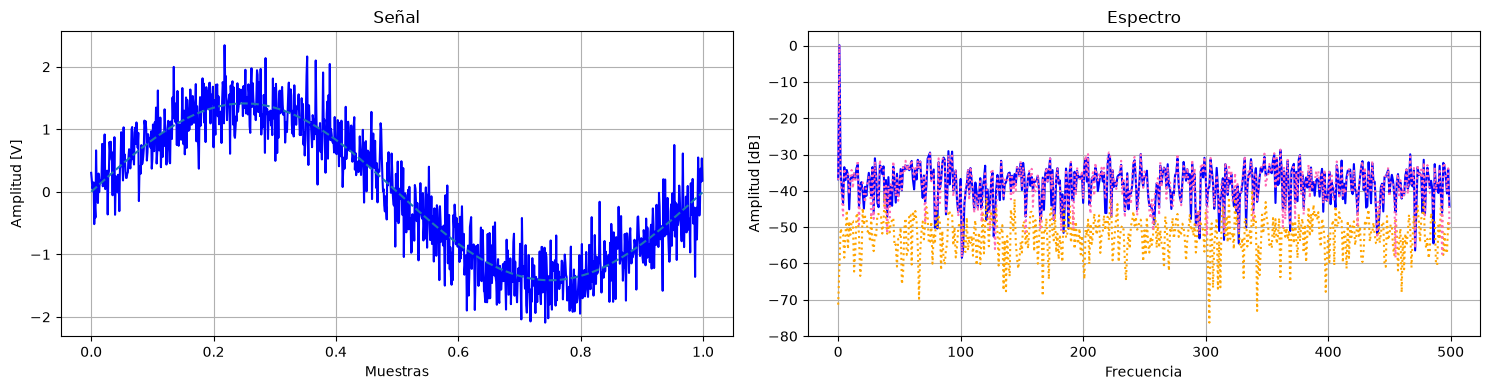

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Thu Sep  3 21:40:08 2026

@author: bruno
"""

import numpy as np
import matplotlib.pyplot as plt

def func_seno(vmax, dc, ff, ph, nn, fs):
    xx=dc+vmax*np.sin(2*np.pi*ff*nn/fs+2*np.pi*ph)
    tt=nn/fs
    return (tt,xx)

def mdbn (señal): #devuelve el modulo de la señal normalizado en 0dB
    
    señal_tr = (1/N) * np.fft.fft(señal)             # fft normalizada de la señal 
    modulo_señal = np.abs(señal_tr)                # 
    modulo_señal_db = 10 * np.log10(2*(np.abs(modulo_señal[:N//2]))**2)   # pone 0dB como referencia de 1W de potencia
    return (modulo_señal_db)

def ADC (señal, qq):
    señal_cuant = np.round(señal/qq)*qq       # señal cuantizada
    ruido_por_cuant = señal_cuant - señal     # ruido consecuencia por cuantizacion (señal original - señal cuantizada)
    return(señal_cuant, ruido_por_cuant)

def turbo_graficador(frec, modulo_xxrtr_db, modulo_nqtr_db, modulo_xxqtr_db, B, Vfs, qq):
    mra = np.mean(modulo_xxrtr_db)
    mnq = np.mean(modulo_nqtr_db)
    
    fig, (ax1) = plt.subplots(figsize=(16,9))
    ax1.plot(frec, modulo_xxrtr_db, color='blue')                            # señal original (con ruido)
    ax1.plot(frec, modulo_nqtr_db, color='orange'      , linestyle = ':' )   # ruido por cuat
    ax1.plot(frec, modulo_xxqtr_db, color='hotpink'    , linestyle = ':' )   # señal cuantizada
    ax1.plot(frec, [mra]*len(frec), linestyle = '--')   # valor
    ax1.plot(frec, [mnq]*len(frec) , linestyle = '--')   # 
    ax1.set_title(f"Señal muestreada por un ADC de {B} bits, Vref = ±{Vfs}V, q = {qq:.2}")
    ax1.set_xlabel("Frecuencia")
    ax1.set_ylabel("Amplitud [dB]")
    ax1.legend(['señal + ruido (entrada ADC)',
                'ruido por cuantizacion',
                'señal cuantizada',
               f'valor medio del ruido de la señal = {mra:.2f}',
               f'valor medio del ruido cuant = {mnq:.2f}'])
    
    ax1.grid(True)
        
    plt.tight_layout()
    plt.show()
    
def graficar_par(x1, y1, xx, x2, y2, y3, y4, color1):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
    
    ax1.plot(x1, y1, color='blue')
    ax1.plot(x1, xx, linestyle = '--') 
    ax1.set_title("Señal")
    ax1.set_xlabel("Muestras")
    ax1.set_ylabel("Amplitud [V]")
    ax1.grid(True)
    
    ax2.plot(x2, y2, color='blue')
    ax2.plot(x2, y3, color='orange', linestyle = ':' )
    ax2.plot(x2, y4, color='hotpink' , linestyle = ':' )
    ax2.set_title("Espectro")
    ax2.set_xlabel("Frecuencia")
    ax2.set_ylabel("Amplitud [dB]")
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

## 
fs = 1000                     # frecuencia de muestreo
N = 1000                      # muestras
nn = np.arange(0,N)           # vector de muestras
df = fs/N                     # Delta f
frec= np.arange(N//2) * fs/N  # vector de frecuencia

## parametros de señal
Pseno = 1                   # potencia seno
vmax = np.sqrt(Pseno*2)     # (potencial máximo aka apmlitud máxima)
dc = 0                      # valor de continua
k = 1                       # escala de frecuencia discreta
kdf = k*df                  # frecuencia de señal en funcion de df
ph = 0                      # fase

#### parametros ADC
kn = 5                       # escala de potencia de ruido
B = 4                          # Bits de ADC
Vfs = 2                         # V de referencia del ADC
qq = 2*Vfs/(2**B)               # paso de cuantizacion (tamaño del escalon)
Pq = kn*(qq**2)/12              # Potencia ruido de cuantizacion

## parametros de ruido analogico
Pn = kn*Pq                        # potencia del ruido analogico en funcion de Pq
mu = 0                            # media de ruido analogico
pot_ruido = np.sqrt(Pn)           # desviacion estandard
snr = 10*np.log10(Pseno/Pn)
ruido = np.random.normal(mu , pot_ruido , N)    # generador de ruido

## señal + ruido
tt, xx = func_seno(vmax, dc, kdf, ph, nn, fs)   # xx es mi señal oiginal
xxr = xx + ruido # señal con ruido
## 

## ADC le paso la señal y el q
xxq, nq = ADC(xxr, qq) 

modulo_xxrtr_db = mdbn(xxr)
modulo_xxqtr_db = mdbn(xxq)
modulo_nqtr_db = mdbn(nq)

graficar_par(tt, xxr, xx, frec, modulo_xxrtr_db, modulo_nqtr_db, modulo_xxqtr_db, 'red')

# turbo_graficador(frec, modulo_xxrtr_db, modulo_nqtr_db, modulo_xxqtr_db, B, Vfs, qq)